In [1]:
# =========================================================
# PD06: PYTHON-SQL PROJECT
# Load All Datasets
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt


# Load datasets
customers = pd.read_csv("CustomerSQL.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
payments = pd.read_csv("payments.csv")
products = pd.read_csv("products.csv")
sellers = pd.read_csv("sellers.csv")
geolocation = pd.read_csv("geolocation.csv")


# Verify dataset shapes
print("CUSTOMERS:", customers.shape)
print("ORDERS:", orders.shape)
print("ORDER ITEMS:", order_items.shape)
print("PAYMENTS:", payments.shape)
print("PRODUCTS:", products.shape)
print("SELLERS:", sellers.shape)
print("GEOLOCATION:", geolocation.shape)

CUSTOMERS: (99441, 5)
ORDERS: (99441, 8)
ORDER ITEMS: (112650, 7)
PAYMENTS: (103886, 5)
PRODUCTS: (32951, 9)
SELLERS: (3095, 4)
GEOLOCATION: (1000163, 5)


In [2]:
# =========================================================
# PYTHON VISUALIZATION SETUP
# =========================================================

# Convert date columns to datetime format
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_approved_at"] = pd.to_datetime(
    orders["order_approved_at"]
)

orders["order_delivered_carrier_date"] = pd.to_datetime(
    orders["order_delivered_carrier_date"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

print("Date columns converted successfully.")

Date columns converted successfully.


In [3]:
# =========================================================
# BASIC PROBLEM 1
# List all unique cities where customers are located.
# =========================================================

unique_cities = customers["customer_city"].dropna().unique()

print("Total unique cities:", len(unique_cities))
print("\nUnique cities:")
print(unique_cities)

Total unique cities: 4119

Unique cities:
['franca' 'sao bernardo do campo' 'sao paulo' ... 'monte bonito'
 'sao rafael' 'eugenio de castro']


Total orders placed in 2017: 45101


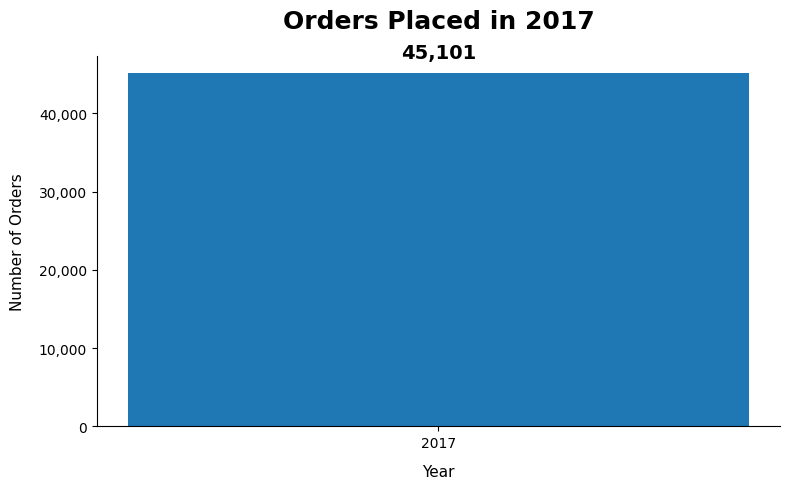

In [4]:
# =========================================================
# BASIC PROBLEM 2
# Count the number of orders placed in 2017.
# =========================================================

orders_2017 = orders[
    (orders["order_purchase_timestamp"] >= "2017-01-01") &
    (orders["order_purchase_timestamp"] < "2018-01-01")
]

total_orders_2017 = len(orders_2017)

print("Total orders placed in 2017:", total_orders_2017)


# =========================================================
# VISUALIZATION
# =========================================================

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ["2017"],
    [total_orders_2017],
    width=0.45
)

# Add value label
ax.annotate(
    f"{total_orders_2017:,}",
    xy=(
        bars[0].get_x() + bars[0].get_width() / 2,
        bars[0].get_height()
    ),
    xytext=(0, 8),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold"
)

# Title
ax.set_title(
    "Orders Placed in 2017",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Axis labels
ax.set_xlabel(
    "Year",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "Number of Orders",
    fontsize=11,
    labelpad=10
)

# Format y-axis numbers
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{int(x):,}")
)

# Clean appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.show()

Top 8 product categories by total sales:
        product_category  total_sales
30         HEALTH BEAUTY   1258681.34
45       Watches present   1205005.68
49        bed table bath   1036988.68
68         sport leisure    988048.97
53  computer accessories    911954.32
24  Furniture Decoration    729762.49
13            Cool Stuff    635290.85
61            housewares    632248.66


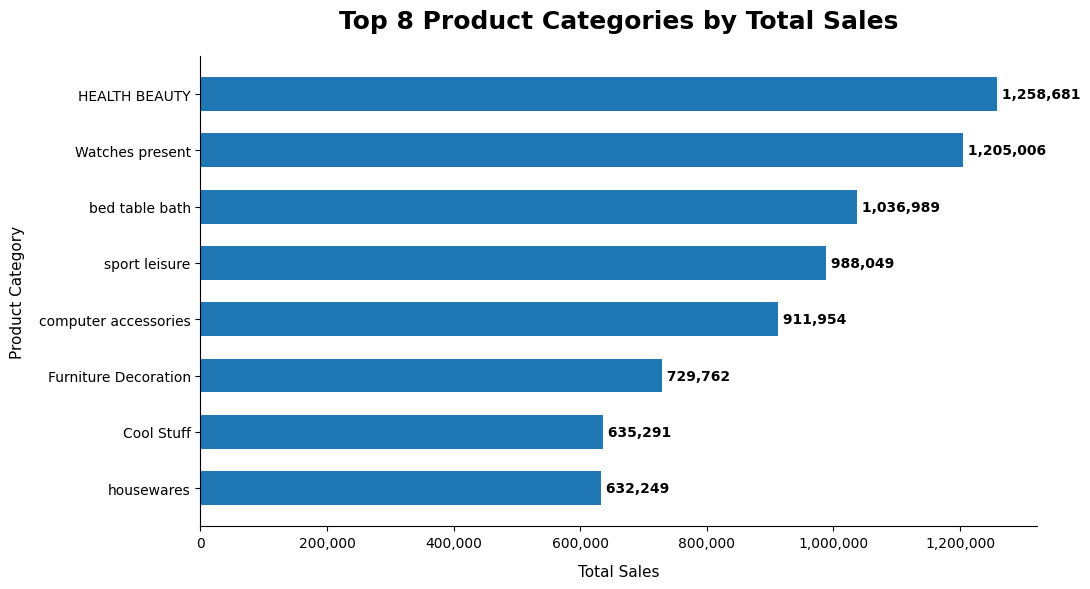

In [5]:
# =========================================================
# BASIC PROBLEM 3
# Find the total sales per category.
# =========================================================

# Calculate total sales by product category
sales_by_category = (
    order_items
    .merge(
        products[["product_id", "product category"]],
        on="product_id",
        how="inner"
    )
    .groupby("product category", as_index=False)["price"]
    .sum()
    .rename(columns={
        "product category": "product_category",
        "price": "total_sales"
    })
    .sort_values("total_sales", ascending=False)
)

# Select top 8 categories
top_8_categories = sales_by_category.head(8)

print("Top 8 product categories by total sales:")
print(top_8_categories)


# =========================================================
# VISUALIZATION
# =========================================================

top_8_plot = top_8_categories.sort_values(
    "total_sales",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    top_8_plot["product_category"],
    top_8_plot["total_sales"],
    height=0.6
)

# Add sales values
for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Top 8 Product Categories by Total Sales",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Axis labels
ax.set_xlabel(
    "Total Sales",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "Product Category",
    fontsize=11,
    labelpad=10
)

# Format x-axis
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{x:,.0f}")
)

# Clean appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.show()

Percentage of orders paid in installments: 51.46%


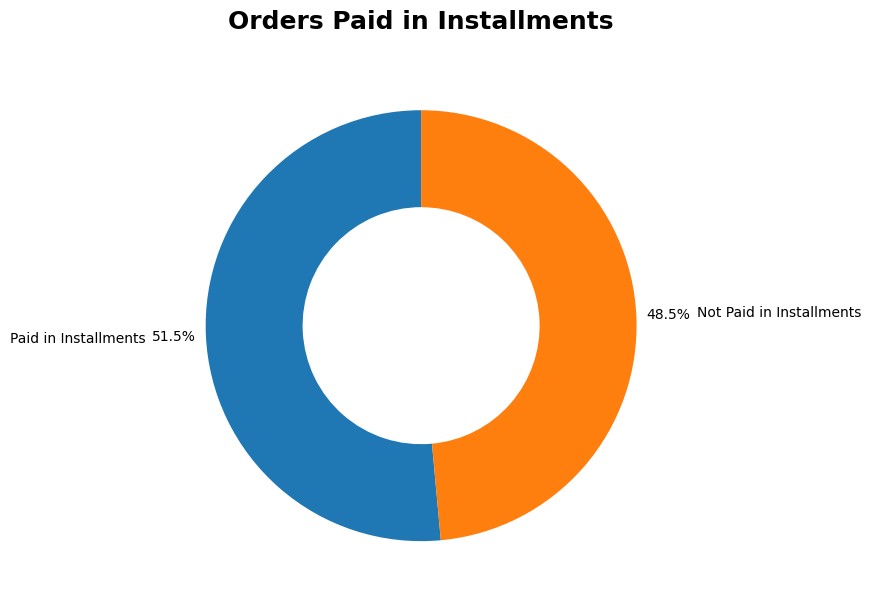

In [6]:
# =========================================================
# BASIC PROBLEM 4
# Calculate the percentage of orders that were paid
# in installments.
# =========================================================

installment_orders = payments[
    payments["payment_installments"] > 1
]["order_id"].nunique()

total_orders = payments["order_id"].nunique()

installment_percentage = (
    installment_orders / total_orders
) * 100

non_installment_percentage = 100 - installment_percentage

print(
    f"Percentage of orders paid in installments: "
    f"{installment_percentage:.2f}%"
)


# =========================================================
# VISUALIZATION
# =========================================================

labels = [
    "Paid in Installments",
    "Not Paid in Installments"
]

values = [
    installment_percentage,
    non_installment_percentage
]

fig, ax = plt.subplots(figsize=(8, 7))

ax.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=1.15,
    labeldistance=1.28,
    wedgeprops=dict(width=0.45)
)

ax.set_title(
    "Orders Paid in Installments",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

Number of customers from each state:
   customer_state  customer_count
25             SP           41746
18             RJ           12852
10             MG           11635
22             RS            5466
17             PR            5045
23             SC            3637
4              BA            3380
6              DF            2140
7              ES            2033
8              GO            2020
15             PE            1652
5              CE            1336
13             PA             975
12             MT             907
9              MA             747
11             MS             715
14             PB             536
16             PI             495
19             RN             485
1              AL             413
24             SE             350
26             TO             280
20             RO             253
2              AM             148
0              AC              81
3              AP              68
21             RR              46


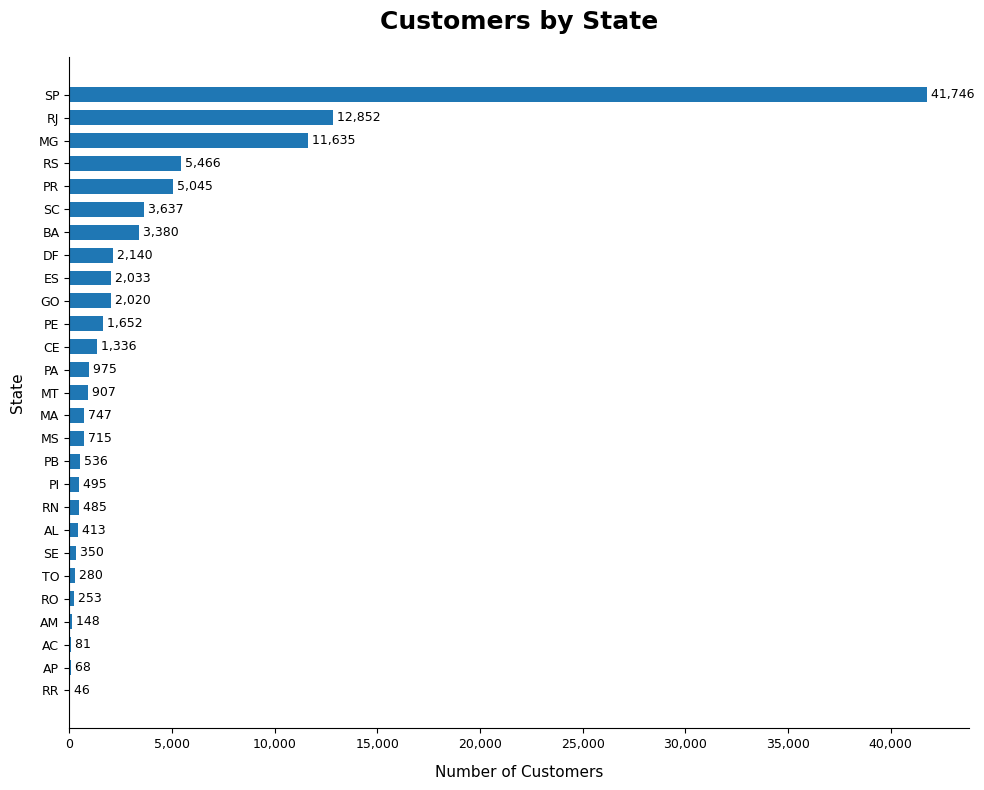

In [7]:
# =========================================================
# BASIC PROBLEM 5
# Count the number of customers from each state.
# =========================================================

customers_by_state = (
    customers
    .groupby("customer_state")
    .size()
    .reset_index(name="customer_count")
    .sort_values("customer_count", ascending=True)
)

print("Number of customers from each state:")
print(
    customers_by_state.sort_values(
        "customer_count",
        ascending=False
    )
)


# =========================================================
# VISUALIZATION
# =========================================================

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    customers_by_state["customer_state"],
    customers_by_state["customer_count"],
    height=0.65
)

# Add values
for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:,}",
        va="center",
        fontsize=9
    )

ax.set_title(
    "Customers by State",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Number of Customers",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "State",
    fontsize=11,
    labelpad=10
)

# Format x-axis
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{int(x):,}")
)

ax.tick_params(axis="both", labelsize=9)

# Clean appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Number of orders per month in 2018:
  month_name  order_count
0        Jan         7269
1        Feb         6728
2        Mar         7211
3        Apr         6939
4        May         6873
5        Jun         6167
6        Jul         6292
7        Aug         6512
8        Sep           16
9        Oct            4


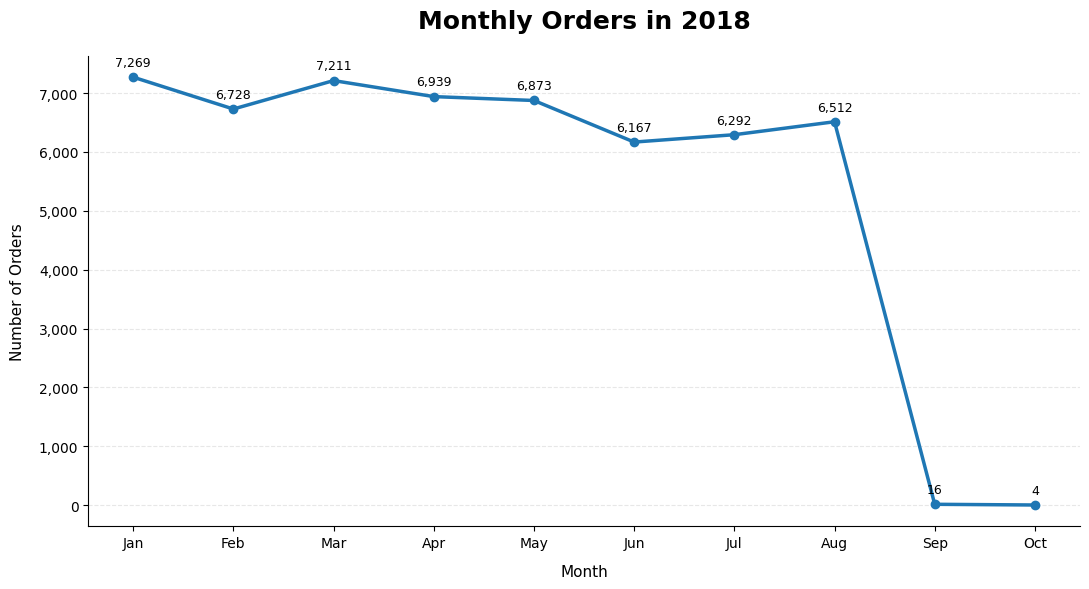

In [8]:
# =========================================================
# INTERMEDIATE PROBLEM 1
# Calculate the number of orders per month in 2018.
# =========================================================

orders_2018 = orders[
    (orders["order_purchase_timestamp"] >= "2018-01-01") &
    (orders["order_purchase_timestamp"] < "2019-01-01")
].copy()

orders_2018["month"] = orders_2018[
    "order_purchase_timestamp"
].dt.month

monthly_orders_2018 = (
    orders_2018
    .groupby("month")
    .size()
    .reset_index(name="order_count")
)

# Keep all 12 months in order
monthly_orders_2018 = monthly_orders_2018.sort_values("month")

# Month names
month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_orders_2018["month_name"] = monthly_orders_2018[
    "month"
].apply(lambda x: month_names[x - 1])

print("Number of orders per month in 2018:")
print(
    monthly_orders_2018[
        ["month_name", "order_count"]
    ]
)


# =========================================================
# VISUALIZATION
# =========================================================

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    monthly_orders_2018["month_name"],
    monthly_orders_2018["order_count"],
    marker="o",
    linewidth=2.5
)

# Add values above points
for x, y in zip(
    monthly_orders_2018["month_name"],
    monthly_orders_2018["order_count"]
):
    ax.annotate(
        f"{y:,}",
        (x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.set_title(
    "Monthly Orders in 2018",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Month",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "Number of Orders",
    fontsize=11,
    labelpad=10
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{int(x):,}")
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.show()

Average number of products per order by customer city:
       customer_city  average_products_per_order
2619  padre carvalho                         7.0
907      celso ramos                         6.5
1154           datas                         6.0
756    candido godoi                         6.0
2264  matias olimpio                         5.0
...              ...                         ...
1946         jatauba                         1.0
1947          jatoba                         1.0
1949            jaua                         1.0
1950         jaupaci                         1.0
1935          jardim                         1.0

[4110 rows x 2 columns]


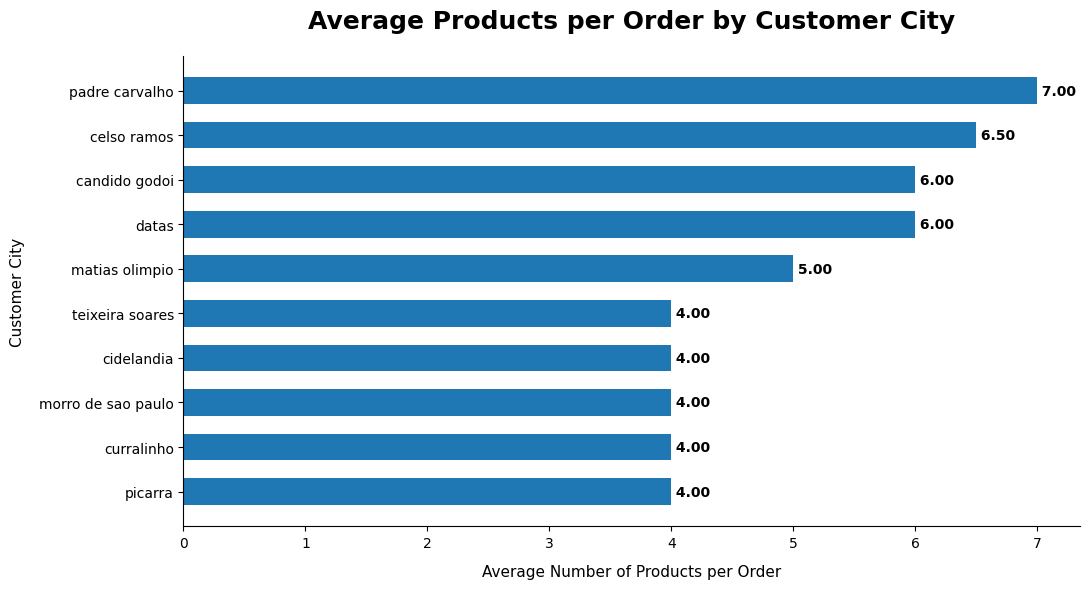

In [9]:
# =========================================================
# INTERMEDIATE PROBLEM 2
# Find the average number of products per order,
# grouped by customer city.
# =========================================================

# Count products in each order
products_per_order = (
    order_items
    .groupby("order_id")
    .size()
    .reset_index(name="product_count")
)

# Connect orders with customer city
order_city_products = (
    orders[["order_id", "customer_id"]]
    .merge(
        products_per_order,
        on="order_id",
        how="inner"
    )
    .merge(
        customers[["customer_id", "customer_city"]],
        on="customer_id",
        how="inner"
    )
)

# Calculate average products per order by city
average_products_by_city = (
    order_city_products
    .groupby("customer_city", as_index=False)["product_count"]
    .mean()
    .rename(columns={
        "product_count": "average_products_per_order"
    })
    .sort_values(
        "average_products_per_order",
        ascending=False
    )
)

print("Average number of products per order by customer city:")
print(average_products_by_city)


# =========================================================
# VISUALIZATION
# =========================================================

top_10_cities = average_products_by_city.head(10).sort_values(
    "average_products_per_order",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    top_10_cities["customer_city"],
    top_10_cities["average_products_per_order"],
    height=0.6
)

# Add values
for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.2f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Average Products per Order by Customer City",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Average Number of Products per Order",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "Customer City",
    fontsize=11,
    labelpad=10
)

ax.tick_params(axis="both", labelsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Percentage of total revenue contributed by each category:
               product_category     revenue  revenue_percentage
30                HEALTH BEAUTY  1258681.34            9.384664
45              Watches present  1205005.68            8.984461
49               bed table bath  1036988.68            7.731735
68                sport leisure   988048.97            7.366843
53         computer accessories   911954.32            6.799485
..                          ...         ...                 ...
58                      flowers     1110.04            0.008276
32              House Comfort 2      760.27            0.005669
50               cds music dvds      730.00            0.005443
18  Fashion Children's Clothing      569.85            0.004249
62       insurance and services      283.29            0.002112

[73 rows x 3 columns]


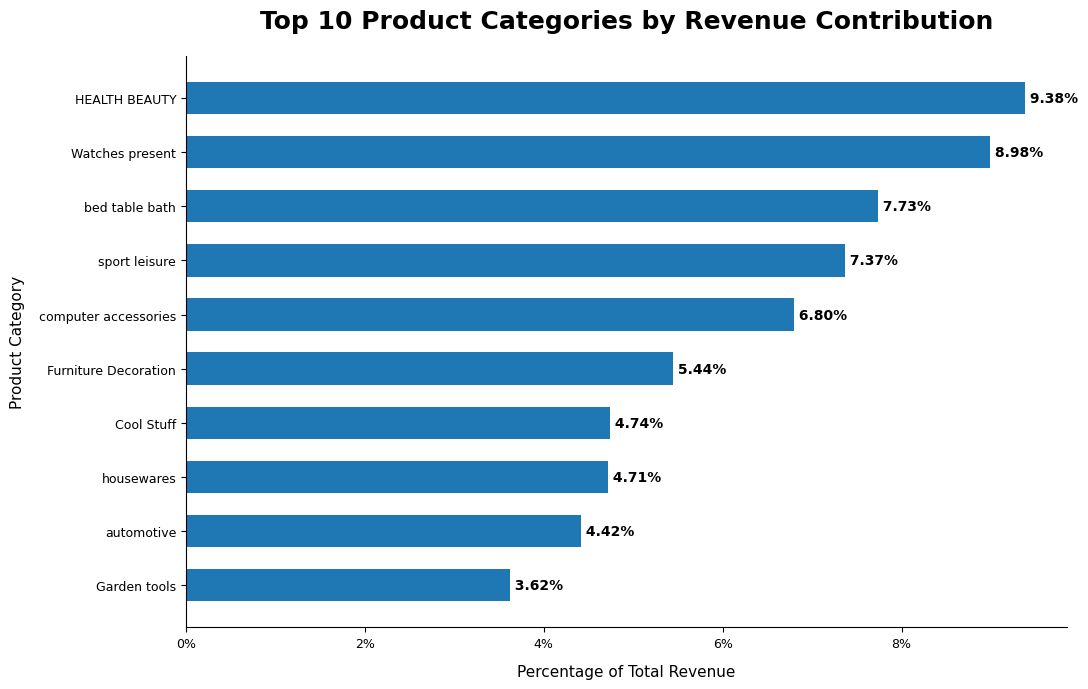

In [10]:
# =========================================================
# INTERMEDIATE PROBLEM 3
# Calculate the percentage of total revenue contributed
# by each product category.
# =========================================================

# Calculate revenue by product category
category_revenue = (
    order_items
    .merge(
        products[["product_id", "product category"]],
        on="product_id",
        how="inner"
    )
    .groupby("product category", as_index=False)["price"]
    .sum()
    .rename(columns={
        "product category": "product_category",
        "price": "revenue"
    })
)

# Calculate percentage of total revenue
total_revenue = category_revenue["revenue"].sum()

category_revenue["revenue_percentage"] = (
    category_revenue["revenue"] / total_revenue
) * 100

category_revenue = category_revenue.sort_values(
    "revenue_percentage",
    ascending=False
)

print("Percentage of total revenue contributed by each category:")
print(category_revenue)


# =========================================================
# VISUALIZATION — TOP 10
# =========================================================

top_10_categories = (
    category_revenue
    .head(10)
    .sort_values("revenue_percentage", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    top_10_categories["product_category"],
    top_10_categories["revenue_percentage"],
    height=0.6
)

# Add percentage labels
for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.2f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Top 10 Product Categories by Revenue Contribution",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Percentage of Total Revenue",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "Product Category",
    fontsize=11,
    labelpad=10
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{x:.0f}%")
)

ax.tick_params(axis="both", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Correlation between product price and number of times purchased: -0.0321


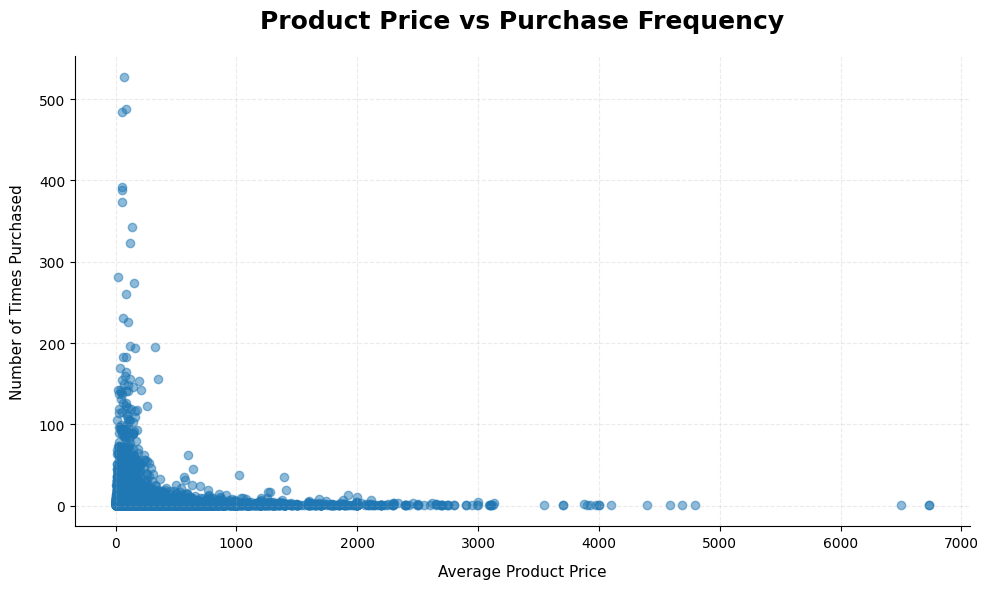

In [11]:
# =========================================================
# INTERMEDIATE PROBLEM 4
# Identify the correlation between product price and the
# number of times a product has been purchased.
# =========================================================

# Calculate average product price and purchase frequency
product_purchase_data = (
    order_items
    .groupby("product_id")
    .agg(
        product_price=("price", "mean"),
        times_purchased=("product_id", "count")
    )
    .reset_index()
)

# Calculate correlation
correlation = product_purchase_data[
    ["product_price", "times_purchased"]
].corr().iloc[0, 1]

print(
    f"Correlation between product price and "
    f"number of times purchased: {correlation:.4f}"
)


# =========================================================
# VISUALIZATION
# =========================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    product_purchase_data["product_price"],
    product_purchase_data["times_purchased"],
    alpha=0.5
)

ax.set_title(
    "Product Price vs Purchase Frequency",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Average Product Price",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "Number of Times Purchased",
    fontsize=11,
    labelpad=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

Seller revenue ranking:
                             seller_id  total_revenue  revenue_rank
857   4869f7a5dfa277a7dca6462dcf3b52b2      229472.63             1
1013  53243585a1d6dc2643021fd1853d8905      222776.05             2
881   4a3ca9315b744ce9f8e9374361493884      200472.92             3
3024  fa1c13f2614d7b5c4749cbc52fecda94      194042.03             4
1535  7c67e1448b00f6e969d365cea6b010ab      187923.89             5
...                                ...            ...           ...
627   34aefe746cd81b7f3b23253ea28bef39           8.00          3091
1370  702835e4b785b67a084280efca355756           7.60          3092
373   1fa2d3def6adfa70e58c276bb64fe5bb           6.90          3093
1465  77128dec4bec4878c37ab7d6169d6f26           6.50          3094
2519  cf6f6bc4df3999b9c6440f124fb2f687           3.50          3095

[3095 rows x 3 columns]


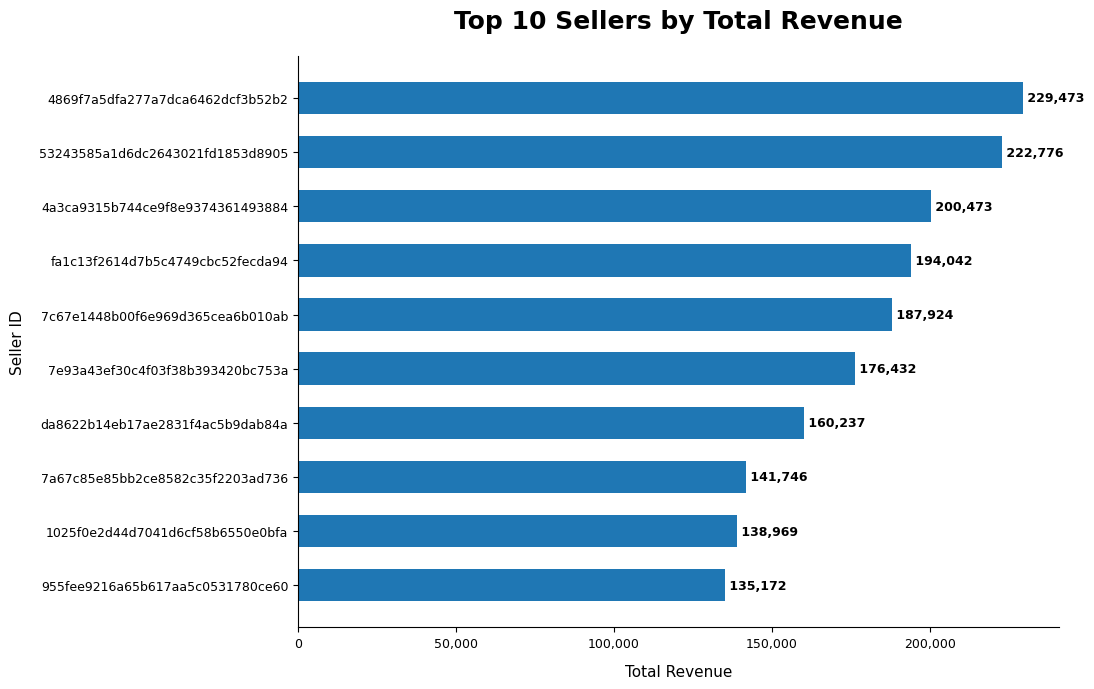

In [12]:
# =========================================================
# INTERMEDIATE PROBLEM 5
# Calculate the total revenue generated by each seller,
# and rank them by revenue.
# =========================================================

# Calculate total revenue generated by each seller
seller_revenue = (
    order_items
    .groupby("seller_id", as_index=False)["price"]
    .sum()
    .rename(columns={
        "price": "total_revenue"
    })
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

# Rank sellers by revenue
seller_revenue["revenue_rank"] = (
    seller_revenue["total_revenue"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

print("Seller revenue ranking:")
print(seller_revenue)


# =========================================================
# VISUALIZATION — TOP 10 SELLERS
# =========================================================

top_10_sellers = (
    seller_revenue
    .head(10)
    .sort_values("total_revenue", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    top_10_sellers["seller_id"],
    top_10_sellers["total_revenue"],
    height=0.6
)

# Add revenue values
for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:,.0f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Top 10 Sellers by Total Revenue",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Total Revenue",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "Seller ID",
    fontsize=11,
    labelpad=10
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{x:,.0f}")
)

ax.tick_params(axis="both", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Moving average of order values for each customer:
                               order_id                customer_unique_id  \
87338  e22acc9c116caa3f2b7121bbb380d08e  0000366f3b9a7992bf8c76cfdf3221e2   
20578  3594e05a005ac4d06a72673270ef9ec9  0000b849f77a49e4a4ce2b2a4ca5be3f   
68939  b33ec3b699337181488304f362a6b734  0000f46a3911fa3c0805444483337064   
25028  41272756ecddd9a9ed0180413cc22fb6  0000f6ccb0745a6a4b88665a16c9f078   
83852  d957021f1127559cd947b62533f484f7  0004aac84e0df4da2b147fca70cf8255   
...                                 ...                               ...   
44061  725cf8e9c24e679a8a5a32cb92c9ce1e  fffcf5a5ff07b0908bd4e2dbc735a684   
76751  c71b9252fd7b3b263aaa4cb09319a323  fffea47cd6d3cc0a88bd621562a9d061   
97828  fdc45e6c7555e6cb3cc0daca2557dbe1  ffff371b4d645b6ecea244b27531430a   
57016  94d3ee0bc2a0af9d4fa47a4d63616e8d  ffff5962728ec6157033ef9805bacc48   
95416  f79a35da168301ae56922475da21117b  ffffd2657e2aad2907e67c3e9daecbeb   

      order_purchase_time

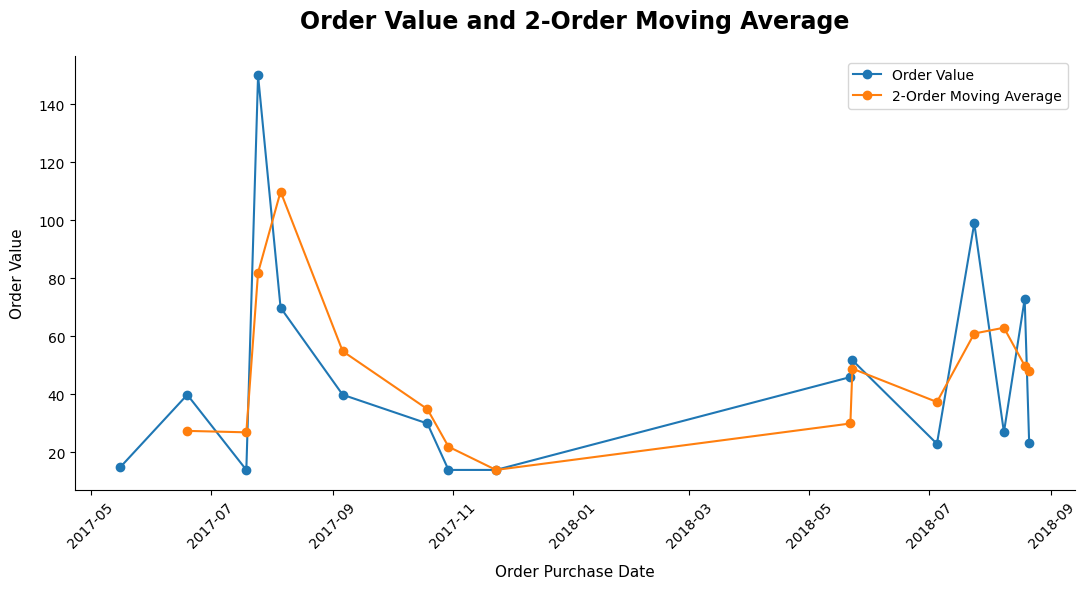

In [13]:
# =========================================================
# ADVANCED PROBLEM 1
# Calculate the moving average of order values for each
# customer over their order history.
# =========================================================

# Add unique customer identifier to orders
orders_with_customer = (
    orders[
        ["order_id", "customer_id", "order_purchase_timestamp"]
    ]
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="inner"
    )
)

# Calculate order value for each order
order_values = (
    orders_with_customer
    .merge(
        order_items[["order_id", "price"]],
        on="order_id",
        how="inner"
    )
    .groupby(
        [
            "order_id",
            "customer_unique_id",
            "order_purchase_timestamp"
        ],
        as_index=False
    )["price"]
    .sum()
    .rename(columns={
        "price": "order_value"
    })
)

# Sort orders by customer and purchase date
order_values = order_values.sort_values(
    ["customer_unique_id", "order_purchase_timestamp"]
)

# Calculate 2-record moving average
order_values["moving_average"] = (
    order_values
    .groupby("customer_unique_id")["order_value"]
    .rolling(window=2)
    .mean()
    .reset_index(level=0, drop=True)
)

print("Moving average of order values for each customer:")
print(order_values)


# =========================================================
# VISUALIZATION
# =========================================================

# Find a customer with multiple orders
customer_order_counts = (
    order_values
    .groupby("customer_unique_id")
    .size()
    .sort_values(ascending=False)
)

customer_id = customer_order_counts.index[0]

customer_data = (
    order_values[
        order_values["customer_unique_id"] == customer_id
    ]
    .sort_values("order_purchase_timestamp")
)

print(f"Customer selected for visualization: {customer_id}")
print(f"Number of orders: {len(customer_data)}")


fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    customer_data["order_purchase_timestamp"],
    customer_data["order_value"],
    marker="o",
    label="Order Value"
)

ax.plot(
    customer_data["order_purchase_timestamp"],
    customer_data["moving_average"],
    marker="o",
    label="2-Order Moving Average"
)

ax.set_title(
    "Order Value and 2-Order Moving Average",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Order Purchase Date",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "Order Value",
    fontsize=11,
    labelpad=10
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Cumulative sales per month for each year:
    year  month  monthly_sales  cumulative_sales
0   2016      9         267.36            267.36
1   2016     10       49507.66          49775.02
2   2016     12          10.90          49785.92
3   2017      1      120312.87         120312.87
4   2017      2      247303.02         367615.89
5   2017      3      374344.30         741960.19
6   2017      4      359927.23        1101887.42
7   2017      5      506071.14        1607958.56
8   2017      6      433038.60        2040997.16
9   2017      7      498031.48        2539028.64
10  2017      8      573971.68        3113000.32
11  2017      9      624401.69        3737402.01
12  2017     10      664219.43        4401621.44
13  2017     11     1010271.37        5411892.81
14  2017     12      743914.17        6155806.98
15  2018      1      950030.36         950030.36
16  2018      2      844178.71        1794209.07
17  2018      3      983213.44        2777422.51
18  2018      4      996647

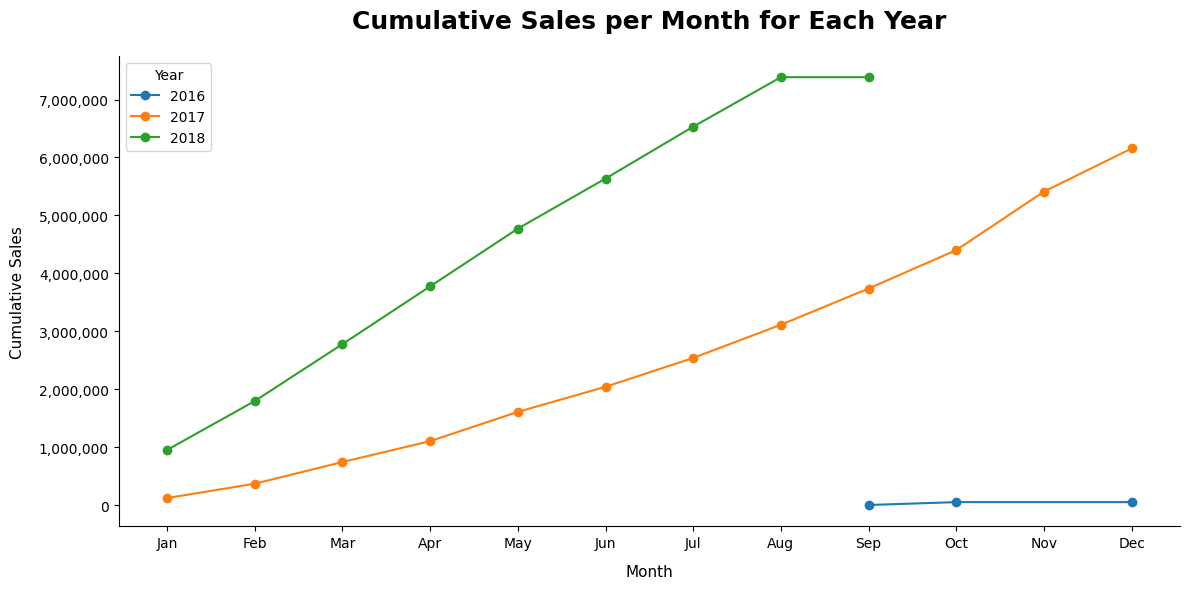

In [14]:
# =========================================================
# ADVANCED PROBLEM 2
# Calculate the cumulative sales per month for each year.
# =========================================================

# Calculate monthly sales
monthly_sales = (
    orders[
        ["order_id", "order_purchase_timestamp"]
    ]
    .merge(
        order_items[["order_id", "price"]],
        on="order_id",
        how="inner"
    )
)

monthly_sales["year"] = (
    monthly_sales["order_purchase_timestamp"].dt.year
)

monthly_sales["month"] = (
    monthly_sales["order_purchase_timestamp"].dt.month
)

monthly_sales = (
    monthly_sales
    .groupby(["year", "month"], as_index=False)["price"]
    .sum()
    .rename(columns={
        "price": "monthly_sales"
    })
    .sort_values(["year", "month"])
)

# Calculate cumulative sales for each year
monthly_sales["cumulative_sales"] = (
    monthly_sales
    .groupby("year")["monthly_sales"]
    .cumsum()
)

print("Cumulative sales per month for each year:")
print(monthly_sales)


# =========================================================
# VISUALIZATION
# =========================================================

monthly_sales["year_month"] = (
    monthly_sales["year"].astype(str)
    + "-"
    + monthly_sales["month"].astype(str).str.zfill(2)
)

fig, ax = plt.subplots(figsize=(12, 6))

for year in monthly_sales["year"].unique():
    year_data = monthly_sales[
        monthly_sales["year"] == year
    ]

    ax.plot(
        year_data["month"],
        year_data["cumulative_sales"],
        marker="o",
        label=str(year)
    )

ax.set_title(
    "Cumulative Sales per Month for Each Year",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Month",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "Cumulative Sales",
    fontsize=11,
    labelpad=10
)

ax.set_xticks(range(1, 13))
ax.set_xticklabels([
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
])

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{x:,.0f}")
)

ax.legend(title="Year")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


Year-over-Year Growth Rate of Total Sales:
   year  total_sales  previous_year_sales  yoy_growth_rate
0  2016     49785.92                  NaN              NaN
1  2017   6155806.98             49785.92     12264.554035
2  2018   7386050.80           6155806.98        19.985094


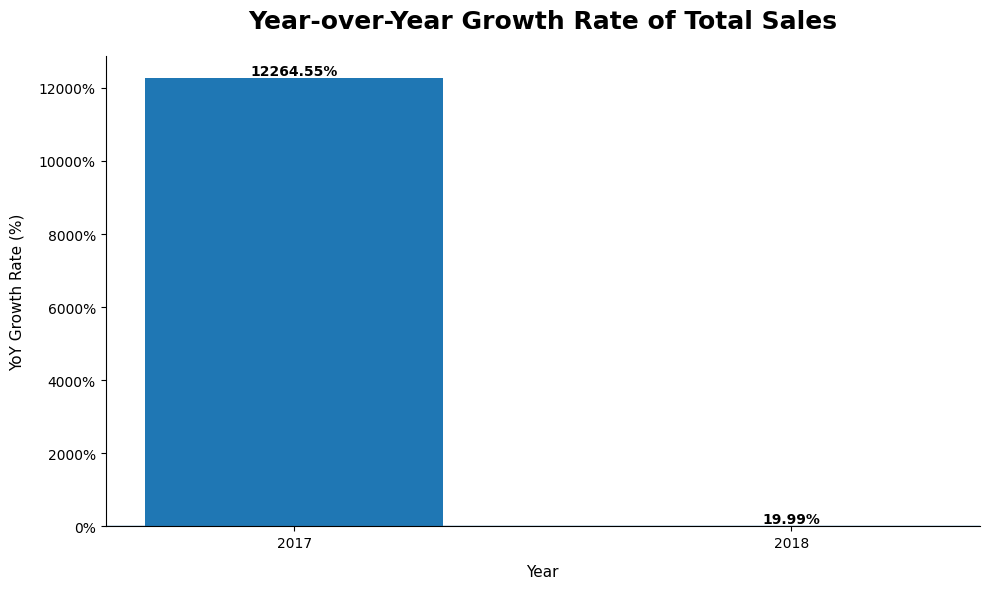

In [15]:
# =========================================================
# ADVANCED PROBLEM 3
# Calculate the year-over-year growth rate of total sales.
# =========================================================

# Calculate total sales for each year
yearly_sales = (
    orders[
        ["order_id", "order_purchase_timestamp"]
    ]
    .merge(
        order_items[["order_id", "price"]],
        on="order_id",
        how="inner"
    )
)

yearly_sales["year"] = (
    yearly_sales["order_purchase_timestamp"].dt.year
)

yearly_sales = (
    yearly_sales
    .groupby("year", as_index=False)["price"]
    .sum()
    .rename(columns={
        "price": "total_sales"
    })
    .sort_values("year")
)

# Calculate previous year's sales
yearly_sales["previous_year_sales"] = (
    yearly_sales["total_sales"].shift(1)
)

# Calculate year-over-year growth rate
yearly_sales["yoy_growth_rate"] = (
    (
        yearly_sales["total_sales"]
        - yearly_sales["previous_year_sales"]
    )
    / yearly_sales["previous_year_sales"]
) * 100

print("Year-over-Year Growth Rate of Total Sales:")
print(yearly_sales)


# =========================================================
# VISUALIZATION
# =========================================================

plot_data = yearly_sales.dropna(
    subset=["yoy_growth_rate"]
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    plot_data["year"].astype(str),
    plot_data["yoy_growth_rate"],
    width=0.6
)

# Add percentage labels
for bar in bars:
    value = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=10,
        fontweight="bold"
    )

ax.axhline(
    0,
    linewidth=1
)

ax.set_title(
    "Year-over-Year Growth Rate of Total Sales",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Year",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "YoY Growth Rate (%)",
    fontsize=11,
    labelpad=10
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{x:.0f}%")
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Total Customers: 96096
Retained Customers: 2234
Retention Rate: 2.32%


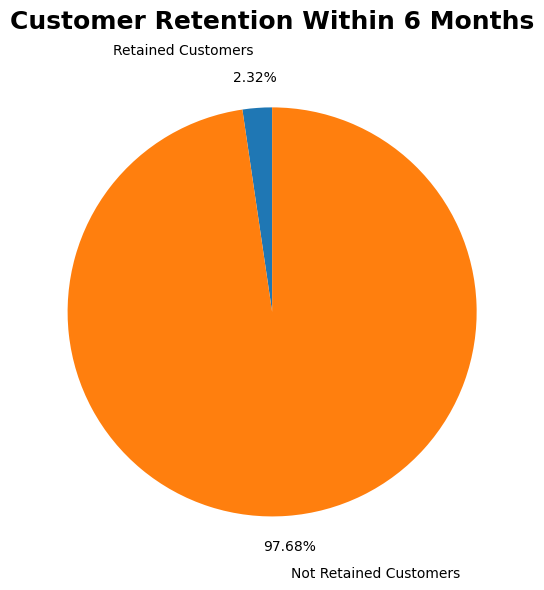

In [16]:
# =========================================================
# ADVANCED PROBLEM 4
# Calculate the retention rate of customers, defined as the
# percentage of customers who make another purchase within
# 6 months of their first purchase.
# =========================================================

# Add unique customer identifier to orders
orders_with_customer = (
    orders[
        ["order_id", "customer_id", "order_purchase_timestamp"]
    ]
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="inner"
    )
)

# Find the first purchase date of each customer
first_purchase = (
    orders_with_customer
    .groupby("customer_unique_id", as_index=False)
    ["order_purchase_timestamp"]
    .min()
    .rename(columns={
        "order_purchase_timestamp": "first_purchase_date"
    })
)

# Join first purchase date back to all orders
customer_orders = orders_with_customer.merge(
    first_purchase,
    on="customer_unique_id",
    how="inner"
)

# Identify customers who made another purchase
# within 6 months of their first purchase
retained_customers = customer_orders[
    (
        customer_orders["order_purchase_timestamp"]
        > customer_orders["first_purchase_date"]
    )
    &
    (
        customer_orders["order_purchase_timestamp"]
        <=
        customer_orders["first_purchase_date"]
        + pd.DateOffset(months=6)
    )
]["customer_unique_id"].drop_duplicates()

# Calculate retention rate
total_customers = first_purchase["customer_unique_id"].nunique()
retained_count = retained_customers.nunique()

retention_rate = (
    retained_count / total_customers
) * 100

print(f"Total Customers: {total_customers}")
print(f"Retained Customers: {retained_count}")
print(f"Retention Rate: {retention_rate:.2f}%")


# =========================================================
# VISUALIZATION
# =========================================================

retention_data = pd.DataFrame({
    "Customer Type": [
        "Retained Customers",
        "Not Retained Customers"
    ],
    "Customer Count": [
        retained_count,
        total_customers - retained_count
    ]
})

fig, ax = plt.subplots(figsize=(8, 6))

wedges, texts, autotexts = ax.pie(
    retention_data["Customer Count"],
    labels=retention_data["Customer Type"],
    autopct="%1.2f%%",
    startangle=90,
    pctdistance=1.15,
    labeldistance=1.28
)

ax.set_title(
    "Customer Retention Within 6 Months",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

Top 3 customers by yearly spending:
                 customer_unique_id  year  total_spent  spending_rank
0  fdaa290acb9eeacb66fa7f979baa6803  2016      1399.00              1
1  753bc5d6efa9e49a03e34cf521a9e124  2016      1299.99              2
2  b92a2e5e8a6eabcc80882c7d68b2c70b  2016      1199.00              3
3  0a0a92112bd4c708ca5fde585afaa872  2017     13440.00              1
4  da122df9eeddfedc1dc1f5349a1a690c  2017      7388.00              2
5  dc4802a71eae9be1dd28f5d788ceb526  2017      6735.00              3
6  763c8b1c9c68a0229c42c9fc6f662b93  2018      7160.00              1
7  459bef486812aa25204be022145caa62  2018      6729.00              2
8  5d0a2980b292d049061542014e8960bf  2018      4599.90              3


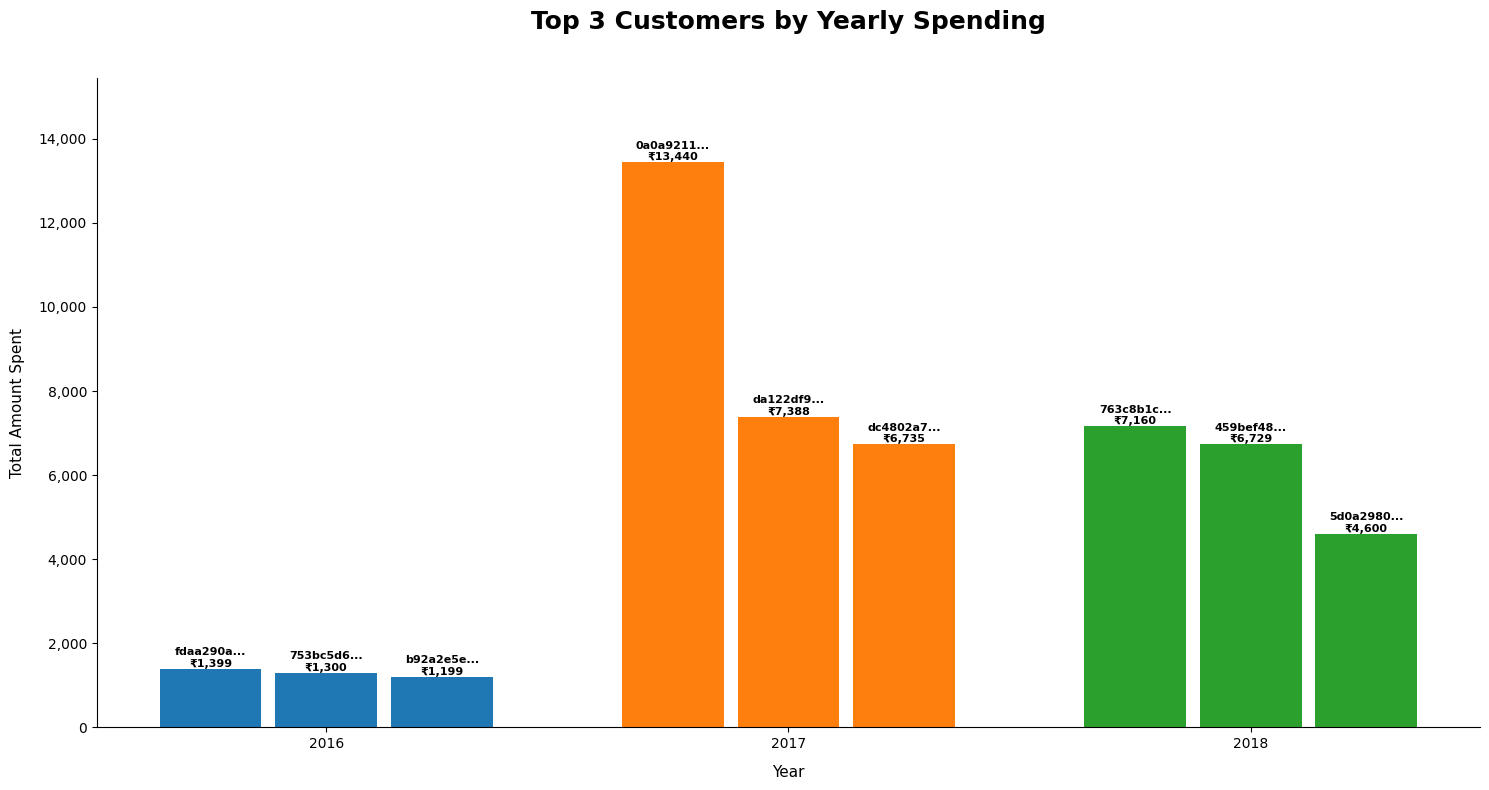

In [17]:
# =========================================================
# ADVANCED PROBLEM 5
# Identify the top 3 customers who spent the most money
# in each year.
# =========================================================

# Merge orders with customer information
# to get the unique customer identifier
customer_order_data = (
    orders[
        [
            "order_id",
            "customer_id",
            "order_purchase_timestamp"
        ]
    ]
    .merge(
        customers[
            [
                "customer_id",
                "customer_unique_id"
            ]
        ],
        on="customer_id",
        how="inner"
    )
)

# Add order item prices
customer_order_data = (
    customer_order_data
    .merge(
        order_items[
            [
                "order_id",
                "price"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

# Extract year from order purchase date
customer_order_data["year"] = (
    customer_order_data["order_purchase_timestamp"]
    .dt.year
)

# =========================================================
# Calculate yearly spending for each customer
# =========================================================

customer_yearly_spending = (
    customer_order_data
    .groupby(
        [
            "customer_unique_id",
            "year"
        ],
        as_index=False
    )["price"]
    .sum()
    .rename(
        columns={
            "price": "total_spent"
        }
    )
)

# =========================================================
# Rank customers within each year
# =========================================================

customer_yearly_spending["spending_rank"] = (
    customer_yearly_spending
    .groupby("year")["total_spent"]
    .rank(
        method="min",
        ascending=False
    )
)

# Keep top 3 customers for each year
top_3_customers = (
    customer_yearly_spending[
        customer_yearly_spending["spending_rank"] <= 3
    ]
    .sort_values(
        [
            "year",
            "spending_rank"
        ]
    )
    .reset_index(drop=True)
)

# Convert rank to integer
top_3_customers["spending_rank"] = (
    top_3_customers["spending_rank"]
    .astype(int)
)

print("Top 3 customers by yearly spending:")
print(top_3_customers)


# =========================================================
# VISUALIZATION — TOP 3 CUSTOMERS BY YEAR
# =========================================================

plot_data = top_3_customers.copy()

# Short customer ID for display
plot_data["customer_label"] = (
    plot_data["customer_unique_id"].str[:8] + "..."
)

years = sorted(
    plot_data["year"].unique()
)

fig, ax = plt.subplots(
    figsize=(15, 8)
)

for i, year in enumerate(years):

    year_data = (
        plot_data[
            plot_data["year"] == year
        ]
        .sort_values("spending_rank")
    )

    positions = [
        i + (j - 1) * 0.25
        for j in range(len(year_data))
    ]

    bars = ax.bar(
        positions,
        year_data["total_spent"],
        width=0.22
    )

    # Add customer ID and spending amount
    for bar, customer_id, spending in zip(
        bars,
        year_data["customer_label"],
        year_data["total_spent"]
    ):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{customer_id}\n₹{spending:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )


# =========================================================
# CHART FORMATTING
# =========================================================

ax.set_title(
    "Top 3 Customers by Yearly Spending",
    fontsize=18,
    fontweight="bold",
    pad=35
)

ax.set_xlabel(
    "Year",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "Total Amount Spent",
    fontsize=11,
    labelpad=10
)

ax.set_xticks(
    range(len(years))
)

ax.set_xticklabels(
    years
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, p: f"{x:,.0f}"
    )
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Give extra space above bars for labels
ax.margins(y=0.15)

plt.tight_layout()
plt.show()